In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/dados_agricolas.csv")

df.head()

,cultura,temperatura,chuva,solo,irrigacao,produtividade
0,milho,28,120,argiloso,sim,6.5
1,milho,30,80,arenoso,não,4.2
2,milho,27,110,argiloso,sim,6.1
3,milho,29,95,misto,não,5.0
4,milho,31,70,arenoso,não,3.8


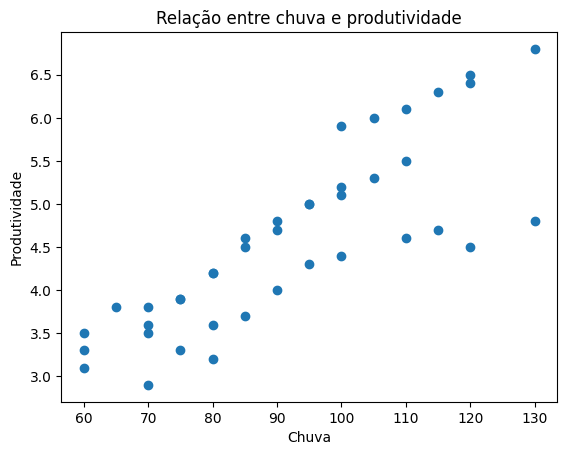

In [2]:
import matplotlib.pyplot as plt

plt.scatter(df["chuva"], df["produtividade"])
plt.xlabel("Chuva")
plt.ylabel("Produtividade")
plt.title("Relação entre chuva e produtividade")

plt.show()

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   cultura        40 non-null     str    
 1   temperatura    40 non-null     int64  
 2   chuva          40 non-null     int64  
 3   solo           40 non-null     str    
 4   irrigacao      40 non-null     str    
 5   produtividade  40 non-null     float64
dtypes: float64(1), int64(2), str(3)
memory usage: 2.6 KB


In [4]:
X = df.drop("produtividade", axis=1)
y = df["produtividade"]

print("Entradas:")
print(X.head())

print("\nSaída:")
print(y.head())

Entradas:
  cultura  temperatura  chuva      solo irrigacao
0   milho           28    120  argiloso       sim
1   milho           30     80   arenoso       não
2   milho           27    110  argiloso       sim
3   milho           29     95     misto       não
4   milho           31     70   arenoso       não

Saída:
0    6.5
1    4.2
2    6.1
3    5.0
4    3.8
Name: produtividade, dtype: float64


In [5]:
X_encoded = pd.get_dummies(X, columns=["cultura", "solo", "irrigacao"], drop_first=True)

X_encoded.head()

,temperatura,chuva,cultura_milho,cultura_soja,solo_argiloso,solo_misto,irrigacao_sim
0,28,120,True,False,True,False,True
1,30,80,True,False,False,False,False
2,27,110,True,False,True,False,True
3,29,95,True,False,False,True,False
4,31,70,True,False,False,False,False


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("Tamanho do treino:", len(X_train))
print("Tamanho do teste:", len(X_test))

Tamanho do treino: 32
Tamanho do teste: 8


In [7]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


In [8]:
y_pred = model.predict(X_test)

print("Previsões:")
print(y_pred)

Previsões:
[3.75975    4.725      3.58441667 4.746      3.58036667 4.51
 5.114      4.154     ]


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)

MAE: 0.20680833333333215
MSE: 0.05671725465277762
R²: 0.8105477923915569


In [10]:
resultado = pd.DataFrame({
    "Real": y_test.values,
    "Previsto": y_pred
})

resultado

,Real,Previsto
0,3.9,3.759750
1,5.0,4.725000
2,3.8,3.584417
3,4.6,4.746000
4,3.8,3.580367
5,4.7,4.510000
6,5.1,5.114000
7,3.7,4.154000


In [11]:
X = df.drop("produtividade", axis=1)
y = df["produtividade"]

In [12]:
X_encoded = pd.get_dummies(X, columns=["cultura", "solo", "irrigacao"], drop_first=True)
X_encoded.head()

,temperatura,chuva,cultura_milho,cultura_soja,solo_argiloso,solo_misto,irrigacao_sim
0,28,120,True,False,True,False,True
1,30,80,True,False,False,False,False
2,27,110,True,False,True,False,True
3,29,95,True,False,False,True,False
4,31,70,True,False,False,False,False


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [15]:
y_pred = model.predict(X_test)

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MAE: 0.20680833333333215
MSE: 0.05671725465277762
R²: 0.8105477923915569


In [13]:
resultado = pd.DataFrame({
    "Real": y_test.values,
    "Previsto": y_pred
})

resultado

,Real,Previsto
0,3.9,3.759750
1,5.0,4.725000
2,3.8,3.584417
3,4.6,4.746000
4,3.8,3.580367
5,4.7,4.510000
6,5.1,5.114000
7,3.7,4.154000


In [18]:
import joblib

# salvar modelo
joblib.dump(model, "../models/model.pkl")

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


In [19]:
# salvar colunas usadas no modelo
joblib.dump(X_encoded.columns, "../models/columns.pkl")

print("Colunas salvas!")

Colunas salvas!


In [20]:
# carregar modelo
model_loaded = joblib.load("../models/model.pkl")

# fazer previsão com dados de teste
pred = model_loaded.predict(X_test)

print(pred[:5])

[3.75975    4.725      3.58441667 4.746      3.58036667]
